#RESNET

In theory, very deep networks can represent very complex functions; but in practice, they are hard to train. Residual Networks, introduced by He et al., allow you to train much deeper networks than were previously practically feasible.


* Here we implement basic building block of ResNets
* Put together these building blocks  to implement and train a state-of-art neural network for image classification.


In [74]:
import numpy as np
from tensorflow.keras import layers, models, initializers, backend as K
from tensorflow.keras.layers import (Input, Add, Dense, Activation, ZeroPadding2D,
                                     BatchNormalization, Flatten, Conv2D,
                                     AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import plot_model, get_file, model_to_dot
from tensorflow.keras.applications.imagenet_utils import preprocess_input

import pydot
from IPython.display import SVG
import scipy
from matplotlib.pyplot import imshow
%matplotlib inline

K.set_image_data_format('channels_last')


The main benefit of a very deep network is that it can represent very complex functions. It can also learn features at many different levels of abstraction, from edges (at the lower layers) to very complex features (at the deeper layers). However, using a deeper network doesn't always help. A huge barrier to training them is vanishing gradients: very deep networks often have a gradient signal that goes to zero quickly, thus making gradient descent unbearably slow. More specifically, during gradient descent, as you backprop from the final layer back to the first layer, you are multiplying by the weight matrix on each step, and thus the gradient can decrease exponentially quickly to zero (or, in rare cases, grow exponentially quickly and "explode" to take very large values).


During training, you might therefore see the magnitude (or norm) of the gradient for the earlier layers descrease to zero very rapidly as training proceeds:

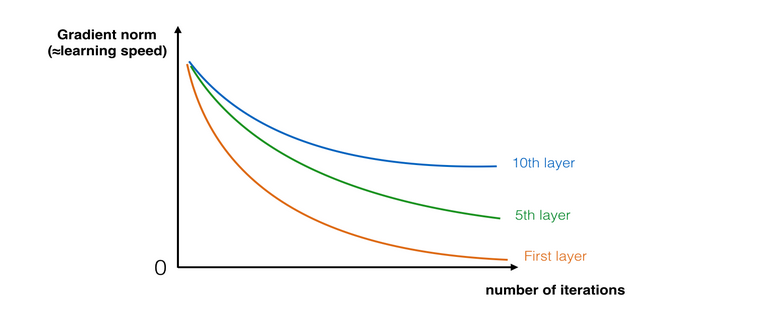

## Building a Residual Network
In ResNets, a "shortcut" or a "skip connection" allows the gradient to be directly backpropagated to earlier layers:


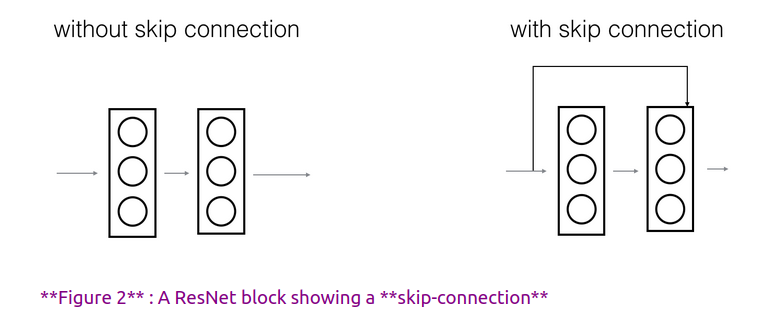

Two main types of blocks are used in a ResNet, depending mainly on whether the input/output dimensions are same or different. We are going to implement both of them.

The identiy block is the standard block used in ResNets , and corresponding to the case where the input activation say$$ a_l $$has the same dim: as the output actication $$a_l+2$$
To flesh out the different steps of what happens in a ResNet's identity , here is an alternate diagram  showing the individual  
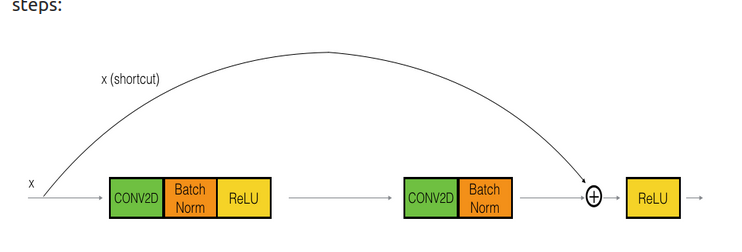

The upper path is the "shortcut path" and lower path is the "main path" . In this diagram we've also made explicit the CONVD and ReLU steps in each layer.To speed up training we've added BatchNorm steps.

We implement a more powerful (slight) version of the identity block, in which the skip connections "skips over 3" hidden layer rather than 2 layer.

*The first CONV2D has F1 filters of shape (1,1) and a stride of (s,s). Its padding is "valid" and its name should be conv_name_base + '2a'.
*  The first BatchNorm is normalizing the channels axis. Its name should be bn_name_base + '2a'.
* Then apply the ReLU activation function. This has no name and no hyperparameters.

The second compoent of the main path
* The second CONV2D has filters of (f,f) and a stride of (1,1). Its padding is "same" and it's name should be conv_name_base + '2b'.
* The second BatchNorm is normalizing the channels axis. Its name should be bn_name_base + '2b'.
* Then apply the ReLU activation function. This has no name and no hyperparameters.

Third component of main path
* The third CONV2D F3 has filters of (1,1) and a stride of (1,1). Its padding is "valid" and it's name should be conv_name_base + '2c'.
* The third BatchNorm is normalizing the channels axis. Its name should be bn_name_base + '2c'. Note that there is no ReLU activation function in this component.

Shortcut path

* The CONV2D F3 has filters of shape (1,1) and a stride of (s,s). Its padding is "valid" and its name should be conv_name_base + '1'.
* The BatchNorm is normalizing the channels axis. Its name should be bn_name_base + '1'.

Final step
* The shortcut and the main path values are added together.
* Then apply the ReLU activation function. This has no name and no hyperparameters.


In [75]:
from tensorflow.keras.initializers import glorot_uniform


In [76]:
def identity_block(X, f, filters, stage, block, s = 2):
  """
  Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network
    s -- Integer, specifying the stride to be used

    Returns:
    X -- output of the convolutional block, tensor of shape (n_H, n_W, n_C)
  """
  # defining name basic
  conv_name_base = 'res' + str(stage) + block + '_branch'
  bn_name_base = "bn" + str(stage) + block + '_branch'

  F1, F2, F3 = filters

  X_shortcut = X

  X = Conv2D(F1, (1, 1), strides = (s,s), name = conv_name_base + '2a', kernel_initializer = glorot_uniform(seed=0))(X)
  X = BatchNormalization(axis=3, name= bn_name_base + "2a")(X)
  X = Activation('relu')(X)

  # Second component of main path
  X = Conv2D(F2, (f, f), strides= (1, 1), padding= 'same', name=conv_name_base + '2b', kernel_initializer= glorot_uniform(seed=0))(X)
  X = BatchNormalization(axis = 3, name = bn_name_base + "2c")(X)
  X = Activation('relu')(X)


  # Third component of main path (~2  lines)
  X = Conv2D(F3, (1, 1), strides= (1, 1), name=conv_name_base + '2c')(X)
  X = BatchNormalization(axis= 3, name=bn_name_base + '2c')(X)

  # Shortcut path
  X_shortcut = Conv2D(F3, (1, 1), strides = (s,s), name = conv_name_base + '1', kernel_initializer = glorot_uniform(seed=0))(X_shortcut)
  X_shortcut = BatchNormalization(axis = 3, name = bn_name_base + '1')(X_shortcut)

  # Final step : Add  shortcut value to main path, and pass it through a RELU activation
  X = layers.Add()([X, X_shortcut])
  X = Activation('relu')(X)


  return X




In [77]:
import tensorflow as tf
import numpy as np
from keras import backend as K

# For reproducibility
np.random.seed(1)
tf.random.set_seed(1)

# Example input
X = np.random.randn(3, 4, 4, 6).astype(np.float32)

# Create a tf.Tensor instead of placeholder
A_prev = tf.convert_to_tensor(X)

# Call your identity block (must be TF 2.x / Keras compatible)
A = identity_block(A_prev, f=2, filters=[2, 4, 6], stage=1, block='a')

# Since TF 2.x is eager, just evaluate the tensor
print("out =", A.numpy()[1][1][0])


out = [0.        0.        0.        0.809044  0.        0.0100501]


## Convolutional Block

We've implemented the ResNet identity block. Next, the ResNet "convolutional block" is the other type of block. We can use this type of block when the input and output dimensions don't match up. The difference with the identity block is that there is a CONV2D layer in the shortcut path:

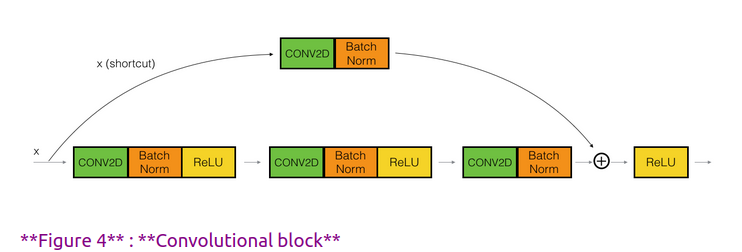

The CONV2D layer in the shortcut path is used to resize  the input **x** to a different dimension, so that the dimensions match up in the final addition needed to add the shortcut value back to the main path.
For example, to reduce the activation dimensions's height and width by a factor of 2, you can use a 1x1 convolution with a stride of 2. The CONV2D layer on the shortcut path does not use any non-linear activation function. Its main role is to just apply a (learned) linear function that reduces the dimension of the input, so that the dimensions match up for the later addition step.

The details of the conv: block is as follows

First component of main path

* The first CONV2D has F1 filters of shape (1,1) and a stride of (s,s). Its padding is "valid" and its name should be `conv_name_base + '2a'`.

* The first BatchNorm is normalizing the channels axis. Its name should be bn_name_base + '2a'.
* Then apply the ReLU activation function. This has no name and no hyperparameters.

Second component of main path:

* The second CONV2D has $$F_2$$ filters of (f,f) and a stride of (1,1). Its padding is "same" and it's name should be conv_name_base + '2b'.

* The second BatchNorm is normalizing the channels axis. Its name should be `bn_name_base + '2b'`.
* Then apply the ReLU activation function. This has no name and no hyperparameters.

Third component of main path:

* The third CONV2D has $$F_3$$ filters of (1,1) and a stride of (1,1). Its padding is "valid" and it's name should be conv_name_base + '2c'.

* The third BatchNorm is normalizing the channels axis. Its name should be bn_name_base + '2c'. Note that there is no ReLU activation function in this component.


Shortcut path
* The CONV2D  has F3 filters of shape (1,1) and a stride of  (s, s) . Its padding is 'valid' its name should be `conv_name_base + '1'`

Final step

* the shortcut and then the main path values are added together
* Then apply the ReLU activation fun. This has no name and no hyperparameters.


In [78]:
def convolutional_block(X, f, filters, stage, block, s=2):
  """ IMplementation of the convolution block has the shape in the figure above
  Arguments :
  X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
  f -- integer, specifying the shape of the middle CONV's window for the main path
  filters -- python list of integers, defining the number of filters in the CONV layers of the main path
  stage -- integer, used to name the layers, depending on their position in the network
  block -- string/character, used to name the layers, depending on their position in the network
  s -- Integer, specifying the stride to be used

  Returns:
       X -- output of the convolutional block, tensor of shape (n_H, n_W, n_C)



  """

  # Naming bases
  conv_name_base = "res" + str(stage) + block + "_branch"
  bn_name_base = "bn" + str(stage) + block + "_branch"

  # Retrieve the filters
  F1, F2, F3 = filters

  # Save the input value for the shortcut
  X_shortcut = X

  # ====================== MAIN PATH ======================

  # First component
  X = Conv2D(F1, (1, 1), strides=(s, s), padding='valid',
              name=conv_name_base+'2a', kernel_initializer=glorot_uniform(seed=0))(X)
  X = BatchNormalization(axis=3, name=bn_name_base+'2a')(X)
  X = Activation('relu')(X)

  # Second component
  X = Conv2D(F2, (f, f), strides=(1, 1), padding='same',
              name=conv_name_base+'2b', kernel_initializer=glorot_uniform(seed=0))(X)
  X = BatchNormalization(axis=3, name=bn_name_base+'2b')(X)
  X = Activation('relu')(X)

  # Third component
  X = Conv2D(F3, (1, 1), strides=(1, 1), padding='valid',
              name=conv_name_base+'2c', kernel_initializer=glorot_uniform(seed=0))(X)
  X = BatchNormalization(axis=3, name=bn_name_base+'2c')(X)

  # ====================== SHORTCUT PATH ======================
  X_shortcut = Conv2D(F3, (1, 1), strides=(s, s), padding='valid',
                      name=conv_name_base+'1', kernel_initializer=glorot_uniform(seed=0))(X_shortcut)
  X_shortcut = BatchNormalization(axis=3, name=bn_name_base+'1')(X_shortcut)

  # Final step: Add shortcut to main path, then ReLU
  X = Add()([X, X_shortcut])
  X = Activation('relu')(X)

  return X






In [79]:
import numpy as np
import tensorflow as tf

# Reproducibility
np.random.seed(1)
tf.random.set_seed(1)

# Example input
X_input = np.random.randn(3, 4, 4, 6).astype(np.float32)
A_prev = tf.convert_to_tensor(X_input)

# Call the convolutional block
A = convolutional_block(A_prev, f=2, filters=[2, 4, 6], stage=1, block='a')

# Print output
print("out =", A.numpy()[1][1][0])


out = [0.         0.         0.         0.8929657  0.         0.19882731]


## Building ResNet50 Model (50 layers)

 The following figure describes in detail the architecture of this neural network. "ID BLOCK" in the diagram stands for "Identity block," and "ID BLOCK x3" means you should stack 3 identity blocks together.

 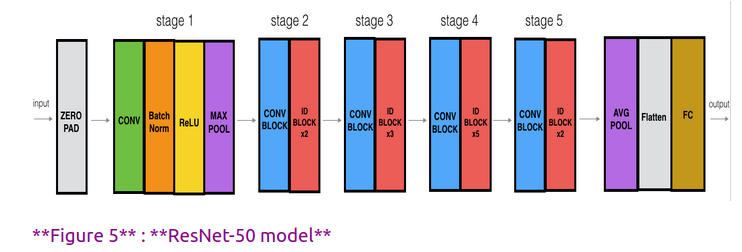

The details of this ResNet-50 model are:

* Zero-padding pads the input with a pad of (3,3)
 * Stage 1:
   * the 2D Conv has 64 filters of shape (7, 7) and uses a stride of (2,2) . Its name is "conv1"
   * BatchNorm is applied to the channels axis of the input.
   * MaxPooling uses a (3,3) window and a (2,2) stride.

 * Stage 2:
   * The convlutional block uses three set of fiters of size [64, 64, 256] "f" is 3, "s" is 1 and the block is "a"
   *  The 2 identity blocks use three set of filters of size [64,64,256], "f" is 3 and the blocks are "b" and "c".
 * Stage 3:
    *   The convolutional block uses three set of filters of size [128,128,512], "f" is 3, "s" is 2 and the block is "a".
    * The 3 identity blocks use three set of filters of size [128,128,512], "f" is 3 and the blocks are "b", "c" and "d".
 * Stage 4:
    * the convolutonal block uses three set of filers  of size [256, 256, 256, 1024]
    "f" is 3, "s" is 2 and block is "a"
    *  The 5 identity blocks use three set of filters of size [256, 256, 1024], "f" is 3 and the blocks are "b", "c", "d", "e" and "f".
 * Stage 5:
   *    The convolutional block uses three set of filters of size [512, 512, 2048], "f" is 3, "s" is 2 and the block is "a".
   * The 2 identity blocks use three set of filters of size [256, 256, 2048], "f" is 3 and the blocks are "b" and "c".
   


* The 2D Average Pooling uses a window of shape (2,2) and its name is "avg_pool".
* The flatten doesn't have any hyperparameters or name.
* The Fully Connected `(Dense)` layer reduces its input to the number of classes using a `softmax activation`. Its name should be `'fc' + str(classes).`


**Here we implement the ResNet with 50 layers. **


In [80]:
from tensorflow.keras.layers import Input, ZeroPadding2D, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform

def ResNet50(input_shape=(64, 64, 3), classes=6):
    """
    Implementation of the popular ResNet50 the following architecture:
    CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3
    -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> TOPLAYER

    Arguments:
        input_shape -- shape of the images of the dataset
        classes -- integer, number of classes

    Returns:
        model -- a Model() instance in Keras
    """

    X_input = Input(input_shape)

    X = ZeroPadding2D((3, 3))(X_input)

    # Stage 1
    X = Conv2D(64, (7, 7), strides=(2, 2), name='conv1',
               kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name='bn_conv1')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f=3, filters=[64, 64, 256], stage=2, block='a', s=1)
    X = identity_block(X, f=3, filters=[64, 64, 256], stage=2, block='b')
    X = identity_block(X, f=3, filters=[64, 64, 256], stage=2, block='c')

    # Stage 3
    X = convolutional_block(X, f=3, filters=[128, 128, 512], stage=3, block='a', s=2)
    X = identity_block(X, f=3, filters=[128, 128, 512], stage=3, block='b')
    X = identity_block(X, f=3, filters=[128, 128, 512], stage=3, block='c')
    X = identity_block(X, f=3, filters=[128, 128, 512], stage=3, block='d')

    # Stage 4
    X = convolutional_block(X, f=3, filters=[256, 256, 1024], stage=4, block='a', s=2)
    X = identity_block(X, f=3, filters=[256, 256, 1024], stage=4, block='b')
    X = identity_block(X, f=3, filters=[256, 256, 1024], stage=4, block='c')
    X = identity_block(X, f=3, filters=[256, 256, 1024], stage=4, block='d')
    X = identity_block(X, f=3, filters=[256, 256, 1024], stage=4, block='e')
    X = identity_block(X, f=3, filters=[256, 256, 1024], stage=4, block='f')

    # Stage 5
    X = convolutional_block(X, f=3, filters=[512, 512, 2048], stage=5, block='a', s=2)
    X = identity_block(X, f=3, filters=[512, 512, 2048], stage=5, block='b')
    X = identity_block(X, f=3, filters=[512, 512, 2048], stage=5, block='c')

    # AVGPOOL / FC layer
    X = Flatten()(X)
    X = Dense(classes, activation='softmax', name='fc' + str(classes),
              kernel_initializer=glorot_uniform(seed=0))(X)

    # Create model
    model = Model(inputs=X_input, outputs=X, name="ResNet50")

    return model


In [81]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add
from tensorflow.keras.initializers import glorot_uniform

def identity_block(X, f, filters, stage, block, training=False):
    """
    Implementation of the identity block for ResNet (TF 2.x)

    Arguments:
    X -- input tensor
    f -- integer, specifying the middle CONV layer window size
    filters -- list of integers, number of filters in each conv layer
    stage -- integer, used for naming
    block -- string/char, used for naming
    training -- boolean, for BatchNorm

    Returns:
    X -- output tensor
    """

    F1, F2, F3 = filters
    X_shortcut = X

    # Naming bases
    conv_name_base = "res" + str(stage) + block + "_branch"
    bn_name_base = "bn" + str(stage) + block + "_branch"

    # First component
    X = Conv2D(F1, (1,1), strides=(1,1), padding='valid',
               name=conv_name_base+'2a', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=bn_name_base+'2a')(X, training=training)
    X = Activation('relu')(X)

    # Second component
    X = Conv2D(F2, (f,f), strides=(1,1), padding='same',
               name=conv_name_base+'2b', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=bn_name_base+'2b')(X, training=training)
    X = Activation('relu')(X)

    # Third component
    X = Conv2D(F3, (1,1), strides=(1,1), padding='valid',
               name=conv_name_base+'2c', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=bn_name_base+'2c')(X, training=training)

    # Add shortcut
    X = Add(name='res'+str(stage)+block+'_add')([X, X_shortcut])
    X = Activation('relu', name='res'+str(stage)+block+'_out')(X)

    return X


In [82]:
model = ResNet50(input_shape=(64, 64, 3), classes=6)


In [83]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [84]:
from google.colab import files
files.upload()


{}

In [85]:
!unzip superhero-dataset.zip

Archive:  superhero-dataset.zip
replace superhero-dataset/batman/Screenshot from 2025-12-29 09-47-24.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-47-24.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-55.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-38.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-28.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-25.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-21.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-15.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-07-40.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-07-29.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-07-21.png  
  inflating: superhero-dataset/batman/Screenshot from 

In [90]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "./superhero-dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(64, 64),
    batch_size=32,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "./superhero-dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(64, 64),
    batch_size=32,
    label_mode="int"
)


Found 154 files belonging to 3 classes.
Using 124 files for training.
Found 154 files belonging to 3 classes.
Using 30 files for validation.


In [97]:
train_ds = train_ds.map(lambda x, y: (x, tf.argmax(y, axis=1)))
val_ds   = val_ds.map(lambda x, y: (x, tf.argmax(y, axis=1)))


In [99]:
for _, y in train_ds.take(1):
    print(y.shape)   # MUST be (batch_size,)


(32,)


In [100]:
model = ResNet50(input_shape=(64, 64, 3), classes=3)


In [101]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [102]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)


Epoch 1/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 74s 6s/step - accuracy: 0.3492 - loss: 12.8859 - val_accuracy: 0.2000 - val_loss: 8532.2246
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 6s/step - accuracy: 0.2872 - loss: 7.5121 - val_accuracy: 0.3667 - val_loss: 115923.1016


In [109]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "./superhero-dataset",
    image_size=(64, 64),
    batch_size=32,
    shuffle=False,
    label_mode="int"
)


Found 154 files belonging to 3 classes.


In [110]:
test_ds = test_ds.map(lambda x, y: (x, tf.cast(y, tf.int32)))


In [111]:
preds = model.evaluate(test_ds)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 416ms/step - accuracy: 0.2879 - loss: 148766.6719


In [112]:
print("Loss =", preds[0])
print("Test Accuracy =", preds[1])


Loss = 125973.8828125
Test Accuracy = 0.33766233921051025


As can be seen the model achives as expected less accuracy because we don't use any of the optimization tech: here , this is enough for this one


In [116]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

img_path = "./image.png"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(64, 64)
)

x = tf.keras.utils.img_to_array(img)
x = x / 255.0                      # SAME normalization as training
x = np.expand_dims(x, axis=0)      # (1, 64, 64, 3)

print("Input image shape:", x.shape)


Input image shape: (1, 64, 64, 3)


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

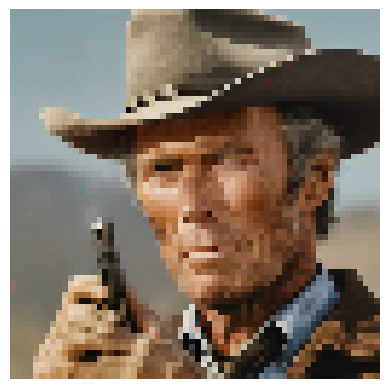

In [117]:
plt.imshow(img)
plt.axis("off")


In [118]:
pred = model.predict(x)
print("Prediction vector:", pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction vector: [[0.3257022  0.39138138 0.2829164 ]]


In [119]:
pred_class = np.argmax(pred, axis=1)[0]

print("Predicted class index:", pred_class)
print("Predicted class name:", class_names[pred_class])


Predicted class index: 1
Predicted class name: spiderman


Pew...! 😀 😀

In [120]:
model.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_7    │ (None, 70, 70, 3) │          0 │ input_layer_7[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 32,    │      9,472 │ zero_padding2d_7… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 32, 32,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_265      │ (None, 32, 32,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 15, 15,    │          0 │ activation_265[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2a      │ (None, 15, 15,    │      4,160 │ max_pooling2d_6[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2a       │ (None, 15, 15,    │        256 │ res2a_branch2a[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_266      │ (None, 15, 15,    │          0 │ bn2a_branch2a[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2b      │ (None, 15, 15,    │     36,928 │ activation_266[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2b       │ (None, 15, 15,    │        256 │ res2a_branch2b[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_267      │ (None, 15, 15,    │          0 │ bn2a_branch2b[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2c      │ (None, 15, 15,    │     16,640 │ activation_267[0… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch1       │ (None, 15, 15,    │     16,640 │ max_pooling2d_6[… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2c       │ (None, 15, 15,    │      1,024 │ res2a_branch2c[0… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch1        │ (None, 15, 15,    │      1,024 │ res2a_branch1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_54 (Add)        │ (None, 15, 15,    │          0 │ bn2a_branch2c[0]

 Total params: 70,730,635 (269.82 MB)

 Trainable params: 23,559,171 (89.87 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 47,118,344 (179.74 MB)